In [ ]:
url = 'https://anaconda.org/conda-forge/libta-lib/0.4.0/download/linux-64/libta-lib-0.4.0-h166bdaf_1.tar.bz2'
!curl -L $url | tar xj -C /usr/lib/x86_64-linux-gnu/ lib --strip-components=1
!pip install conda-package-handling
!wget https://anaconda.org/conda-forge/ta-lib/0.5.1/download/linux-64/ta-lib-0.5.1-py311h9ecbd09_0.conda
!cph x ta-lib-0.5.1-py311h9ecbd09_0.conda
!mv ./ta-lib-0.5.1-py311h9ecbd09_0/lib/python3.11/site-packages/talib /usr/local/lib/python3.11/dist-packages/
import talib

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  4123    0  4123    0     0  11199      0 --:--:-- --:--:-- --:--:-- 11173
100  517k  100  517k    0     0   457k      0  0:00:01  0:00:01 --:--:--  457k
--2025-08-09 19:54:37--  https://anaconda.org/conda-forge/ta-lib/0.5.1/download/linux-64/ta-lib-0.5.1-py311h9ecbd09_0.conda
Resolving anaconda.org (anaconda.org)... 104.19.145.37, 104.19.144.37, 2606:4700::6813:9125, ...
Connecting to anaconda.org (anaconda.org)|104.19.145.37|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://binstar-cio-packages-prod.s3.amazonaws.com/5f738b4b78d4370a69f82984/673b62920c609ff6945bb24d?response-content-disposition=attachment%3B%20filename%3D%22ta-lib-0.5.1-py311h9ecbd09_0.conda%22%3B%20filename%2A%3DUTF-8%27%27ta-lib-0.5.1-py311h9ecbd09_0.conda&response-content-type=application%2Foctet-stream&X-Amz-Algorithm=

In [ ]:
# On MacOS, it's much easier
# brew install ta-lib
# pip install TA-lib

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime

import multiprocessing
from multiprocessing import Pool

import yfinance as yf
import talib
import sys

In [ ]:
start = '2010-01-01'
end = '2024-12-31'

tickers = ['VNQ', 'SPY', 'GLD', 'BTC-USD']

benchmark_weights = np.array([0.1, 0.8, 0.05, 0.05, 0])

In [ ]:
df = yf.download(tickers, start=start, end=end)
df = df['Close']
df = df.dropna().copy()

/tmp/ipython-input-2068362348.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start=start, end=end)
[*********************100%***********************]  4 of 4 completed


In [ ]:
# compute RSI
for ticker in tickers:
    df[f'{ticker}_RSI'] = talib.RSI(df[ticker], timeperiod=14) / 50 - 1 # [-1, +1]

In [ ]:
# compute MACD
for ticker in tickers:
  macd, signal, hist = talib.MACD(
      df[ticker], fastperiod=12, slowperiod=26, signalperiod=9)
  df[f'{ticker}_MACD'] = macd / df[ticker] * 10
  df[f'{ticker}_MACD_signal'] = signal / df[ticker] * 10

In [ ]:
# split into train and test
n_train = int(len(df) * 0.8)
df_train = df.iloc[:n_train]
df_test = df.iloc[n_train:]

In [ ]:
# make environment

class Env:
  def __init__(self, df, tickers, lag=5):
    self.columns = []
    for ticker in tickers:
      self.columns += [
          f'{ticker}_RSI',
          f'{ticker}_MACD',
          f'{ticker}_MACD_signal',
      ]
    dropped = df.dropna()
    self.states = dropped[self.columns].to_numpy()
    self.prices = dropped[tickers].to_numpy() # used for computing returns
    self.lag = lag

  def reset(self):
    self.pos = self.lag
    return self.states[:self.pos].flatten()

  def step(self, action):
    # action space has dimension = #assets + 1 (for cash)
    if action.shape[-1] != self.prices.shape[-1] + 1:
      raise Exception(
          f'Action has the wrong shape. Expected {self.prices.shape[-1] + 1}, got {action.shape[-1]}'
      )

    # compute return for this period
    next_pos = self.pos + self.lag
    asset_returns = (self.prices[next_pos] - self.prices[self.pos]) / self.prices[self.pos]
    asset_returns = np.concatenate((asset_returns, [0]))
    pct_range = action @ asset_returns # reward

    # update pointer
    self.pos = next_pos

    # are we done?
    # done if the next-next position doesn't exist in states array
    # (because there will be no next state)
    done = self.pos + self.lag >= len(self.states)

    # return next_state, reward, done
    return self.states[self.pos - self.lag:self.pos].flatten(), pct_range, done, asset_returns


In [ ]:
def relu(x):
  return x * (x > 0)

def softmax(a):
  c = np.max(a, axis=-1, keepdims=True)
  e = np.exp(a - c)
  return e / e.sum(axis=-1, keepdims=True)

In [ ]:
class ANN:
  def __init__(self, D, M, K, f=relu):
    self.D = D
    self.M = M
    self.K = K
    self.f = f

  def init(self):
    D, M, K = self.D, self.M, self.K
    self.W1 = np.random.randn(D, M) / np.sqrt(D)
    # self.W1 = np.zeros((D, M))
    self.b1 = np.zeros(M)
    self.W2 = np.random.randn(M, K) / np.sqrt(M)
    # self.W2 = np.zeros((M, K))
    self.b2 = np.zeros(K)

  def forward(self, X):
    Z = self.f(X.dot(self.W1) + self.b1)
    return Z.dot(self.W2) + self.b2

  # def sample_action(self, x):
  #   # assume input is a single state of size (D,)
  #   # first make it (N, D) to fit ML conventions
  #   X = np.atleast_2d(x)
  #   Y = self.forward(X)
  #   return Y[0] # the first row

  def get_params(self):
    # return a flat array of parameters
    return np.concatenate([self.W1.flatten(), self.b1, self.W2.flatten(), self.b2])

  def get_params_dict(self):
    return {
      'W1': self.W1,
      'b1': self.b1,
      'W2': self.W2,
      'b2': self.b2,
    }

  def set_params(self, params):
    # params is a flat list
    # unflatten into individual weights
    D, M, K = self.D, self.M, self.K
    self.W1 = params[:D * M].reshape(D, M)
    self.b1 = params[D * M:D * M + M]
    self.W2 = params[D * M + M:D * M + M + M * K].reshape(M, K)
    self.b2 = params[-K:]

In [ ]:
class OnlineStandardScaler:
  def __init__(self, num_inputs):
    self.n = 0
    self.mean = np.zeros(num_inputs)
    self.ssd = np.zeros(num_inputs)

  def partial_fit(self, X):
    self.n += 1
    delta = X - self.mean
    self.mean += delta / self.n
    delta2 = X - self.mean
    self.ssd += delta * delta2

  def transform(self, X):
    m = self.mean
    v = (self.ssd / self.n).clip(min=1e-2)
    s = np.sqrt(v)
    return (X - m) / s

In [ ]:
class Adam:
  def __init__(self, params, lr, beta1=0.9, beta2=0.999, eps=1e-8):
    self.lr = lr
    self.m = 0 # first moment
    self.v = 0 # second moment
    self.b1 = beta1
    self.b2 = beta2
    self.eps = eps
    self.t = 1 # time step
    self.params = params

  def update(self, g):
    # new m
    self.m = self.b1 * self.m + (1 - self.b1) * g
    # new v
    self.v = self.b2 * self.v + (1 - self.b2) * g**2
    # bias correction
    m_hat = self.m / (1 - self.b1**self.t)
    v_hat = self.v / (1 - self.b2**self.t)
    # update time step
    self.t += 1
    # update params
    self.params += self.lr * m_hat / (np.sqrt(v_hat) + self.eps)
    return self.params

In [ ]:
def evolution_strategy(
  f,
  population_size,
  sigma,
  lr,
  initial_params,
  num_iters,
  pool,
  ):

  # assume initial params is a 1-D array
  num_params = len(initial_params)
  reward_per_iteration = np.zeros(num_iters)

  # create optimizer
  params = initial_params
  adam = Adam(params, lr)

  for t in range(num_iters):
    t0 = datetime.now()
    eps = np.random.randn(population_size, num_params)

    ### slow way
    # R = np.zeros(population_size)
    # for i in range(population_size):
    #   R[i] = f(params + sigma * eps[i])

    ### fast way
    R = pool.map(f, [params + sigma * eps[i] for i in range(population_size)])
    R = np.array(R)

    m = R.mean()
    s = R.std()
    if s == 0:
      # we can't apply the following equation
      print("Skipping")
      continue

    A = (R - m) / s
    reward_per_iteration[t] = m
    g = eps.T @ A / (population_size * sigma)
    params = adam.update(g)

    print("Iter:", t, "Avg Reward:", m, "Max Reward:", R.max(), "Duration:", datetime.now() - t0)

  return params, reward_per_iteration

In [ ]:
def sortino_ratio(returns, target=0):
  downside = returns[returns < target]
  downside_deviation = np.sqrt(np.mean((downside - target) ** 2)) if len(downside) > 0 else 1e-8
  return (np.mean(returns) - target) / downside_deviation

In [ ]:
def sharpe_ratio(returns, risk_free_rate=0):
  excess_returns = returns - risk_free_rate
  sd = np.std(returns, ddof=1)
  return np.mean(excess_returns) / sd if sd > 0 else 0

In [ ]:
D = len(Env(df_train, tickers).reset())
M = 128
K = len(tickers) + 1
scaler = OnlineStandardScaler(D)

In [ ]:
def reward_function(params, df=df_train, plot=False):
  model = ANN(D, M, K)
  model.set_params(params)

  # create environment
  env = Env(df, tickers)

  portfolio_returns = []
  asset_returns = [] # keep track of each individual asset's returns for benchmark
  obs = env.reset()
  done = False
  G = 0 # not needed if we use sortino ratio

  while not done:
    scaler.partial_fit(obs)
    x = scaler.transform(obs)
    logits = model.forward(x)

    # get action
    weights = softmax(logits)

    # perform action
    obs, reward, done, individual_returns = env.step(weights)
    portfolio_returns.append(reward)
    asset_returns.append(individual_returns)

    # update total reward
    G += reward

  # convert to numpy
  portfolio_returns = np.array(portfolio_returns)
  asset_returns = np.array(asset_returns)

  if plot:
    cumulative_gross_return = np.cumprod(1 + portfolio_returns)

    # compute benchmark returns
    benchmark_returns = asset_returns @ benchmark_weights
    cumulative_benchmark_return = np.cumprod(1 + benchmark_returns)

    # plot
    plt.plot(cumulative_gross_return, label='es')
    plt.plot(cumulative_benchmark_return, label='benchmark')
    plt.legend()
    plt.title("Cumulative Gross Return")
    plt.show()

    print("Sortino/Sharpe Ratio for Benchmark:", sharpe_ratio(benchmark_returns))

  return sharpe_ratio(portfolio_returns)

Iter: 0 Avg Reward: 0.15318504279915737 Max Reward: 0.18052163005585742 Duration: 0:00:00.699990
Iter: 1 Avg Reward: 0.16786186677636483 Max Reward: 0.19411919922823465 Duration: 0:00:00.957337
Iter: 2 Avg Reward: 0.1790004050395144 Max Reward: 0.19864157528386953 Duration: 0:00:00.992397
Iter: 3 Avg Reward: 0.1947437135951645 Max Reward: 0.2165214929213703 Duration: 0:00:00.974886
Iter: 4 Avg Reward: 0.19868586256832704 Max Reward: 0.22621092689669617 Duration: 0:00:00.868700
Iter: 5 Avg Reward: 0.21060905363311727 Max Reward: 0.23666484149439973 Duration: 0:00:00.637887
Iter: 6 Avg Reward: 0.2216090385834175 Max Reward: 0.24577540547146268 Duration: 0:00:00.651860
Iter: 7 Avg Reward: 0.23194288045894915 Max Reward: 0.2557524385439922 Duration: 0:00:00.616015
Iter: 8 Avg Reward: 0.2401502882298631 Max Reward: 0.26918017805715283 Duration: 0:00:00.639318
Iter: 9 Avg Reward: 0.2575888188707707 Max Reward: 0.2753552831377993 Duration: 0:00:00.630530
Iter: 10 Avg Reward: 0.262315941670027

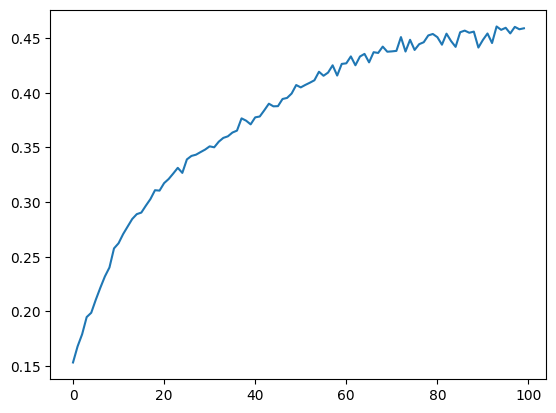

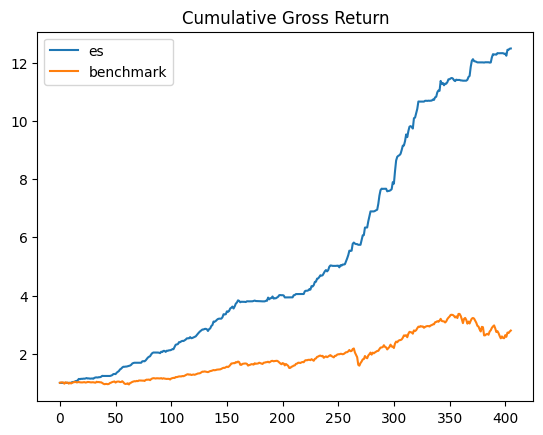

Sortino/Sharpe Ratio for Benchmark: 0.1299380115290395
Test Sortino/Sharpe Ratio: 0.5450445462888159


In [ ]:
if __name__ == '__main__':

  # create model
  model = ANN(D, M, K)

  if len(sys.argv) > 1 and sys.argv[1] == 'play':
    # play with a saved model
    j = np.load('es_dynamic_portfolio_results.npz')
    best_params = np.concatenate([j['W1'].flatten(), j['b1'], j['W2'].flatten(), j['b2']])

  else:
    # pool for parallel evaluation
    pool = Pool(4)

    # train and save model
    model.init()
    params = model.get_params()
    best_params, rewards = evolution_strategy(
      f=reward_function,
      population_size=30,
      sigma=0.05,
      lr=0.02,
      initial_params=params,
      num_iters=100,
      pool=pool,
    )

    # plot the rewards per iteration
    plt.plot(rewards)
    plt.show()

    # save params
    model.set_params(best_params)
    np.savez(
      'es_dynamic_portfolio_results.npz',
      train=rewards,
      **model.get_params_dict(),
    )

  # play with saved model / test episode
  print("Test Sortino/Sharpe Ratio:", reward_function(best_params, plot=True))

![](https://deeplearningcourses.com/notebooks_v3_pxl?sc=8fP_8gnYambvgyDFSyTaIA&n=ES+Dynamic+Portfolio)